In [22]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (14, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

from TB.utils import make_secondary_axis_plot_v2 

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC")

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

In [24]:
tb = TimeseriesBuilder(
    irswaps_tb=IRSwapsTB(mdp=IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")),
    fixedratebonds_tb=FixedRateBondsTB(mdp=FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")),
)

In [29]:
start = datetime.date(2023, 1, 1)
end = datetime.date(2025, 10, 16)

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        # FixedRateBondQuery(cusip="CT30", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT2/CT5/CT10", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT3/CT5/CT10", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT2/CT5/CT7", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT3/CT5/CT7", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="oo2/oo10", value=FixedRateBondValue.YTM), 
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="oo2/oo10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="30Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y/30Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="5y5y/5y10y/5y15y ", value=IRSwapValue.RATE),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="3m2y/3m5y/3m10y", value=IRSwapValue.RATE),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="2Y/5Y/10Y", value=IRSwapValue.CARRY_BPS_RUNNING, value_kwargs={"horizon": "3M"}),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="2Y/5Y/10Y", value=IRSwapValue.ROLL_BPS_RUNNING, value_kwargs={"horizon": "3M"}),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="1y2y/1y5y/1y10y", value=IRSwapValue.ROLL_BPS_RUNNING, value_kwargs={"horizon": "6M"}),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT30", value=IRSwapValue.MMSS),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT30", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="2Y/10Y", value=IRSwapValue.RATE),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y", value=IRSwapValue.SPREADOVER),
    ],
    n_jobs=12,
    # ignore_cache=True
)
df

PRICING USD-SOFR-1D IRSWAPS...: 100%|██████████| 501/501 [00:10<00:00, 46.14it/s]
PRICING FIXED-RATE BONDS.: 0it [00:00, ?it/s]


,SWAPSPREADS
,USD-SOFR-1D CT5/CT30 CURVE MMSS
Date,
2023-01-03,-51.045137
2023-01-04,-52.358250
2023-01-05,-49.019259
2023-01-06,-48.834246
2023-01-09,-48.955347
...,...
2025-10-09,-41.174727
2025-10-10,-41.097084


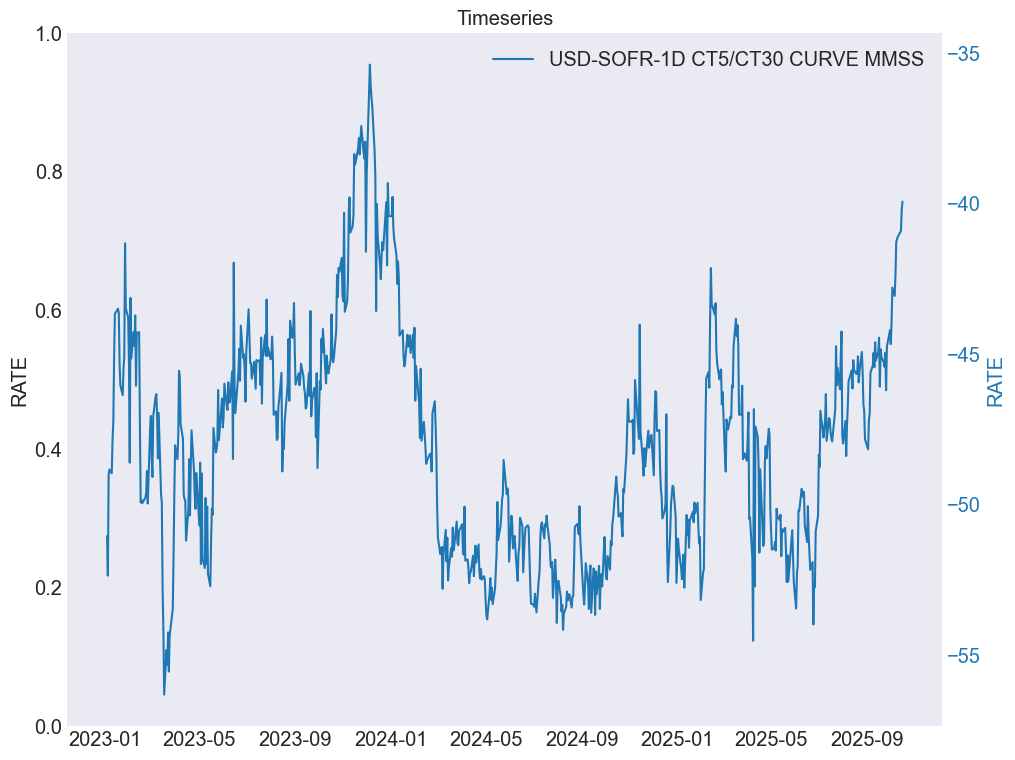

In [31]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot_v2(
    ylabel_left="RATE",
    ylabel_right="RATE",
    title="Timeseries"
)

# plot(df["FRB"]["CT10 OUTRIGHT YTM"], which="left")
# plot(df["FRB"]["CT2/CT5/CT10 FLY YTM"], which="left")
# plot(df["FRB"]["CT3/CT5/CT10 FLY YTM"], which="left")
# plot(df["FRB"]["CT2/CT5/CT7 FLY YTM"], which="right")
# plot(df["FRB"]["CT3/CT5/CT7 FLY YTM"], which="right")
# plot(df["FRB"]["oo2/oo10 CURVE YTM"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT10 OUTRIGHT MMSS"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT2/CT5/CT10 FLY MMSS"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 5Y/10Y CURVE SPREADOVER"], which="right")
# plot(df["IRS"]["USD-SOFR-1D 1y/1y1y/2y1y FLY RATE"], which="left")
# plot(df["IRS"]["USD-SOFR-1D 3m2y/3m5y/3m10y FLY RATE"])
# plot(df["IRS"]["USD-SOFR-1D 1y2y/1y5y/1y10y FLY RATE"], which="left")
# plot(df["IRS"]["USD-SOFR-1D 2y1y/3y1y/4y1y FLY RATE"])
# plot(df["IRS"]["USD-SOFR-1D 3y1y/4y1y/5y1y FLY RATE"])

# plot(df["SWAPSPREADS"]["USD-SOFR-1D 5Y/30Y CURVE SPREADOVER"], which="left")
plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5/CT30 CURVE MMSS"], which="right")

# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT MMSS"])
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 10Y OUTRIGHT SPREADOVER"])
# plot(df["IRS"]["USD-SOFR-1D 2Y/5Y/10Y FLY CARRY_BPS_RUNNING"])
# plot(df["IRS"]["USD-SOFR-1D 2Y/5Y/10Y FLY ROLL_BPS_RUNNING"])
# plot(df["IRS"]["USD-SOFR-1D 2Y/5Y/10Y FLY RATE"])
# plot(df["IRS"]["USD-SOFR-1D 5y5y/5y10y/5y15y FLY RATE"])

legend()
plt.show()




# plt.plot(df.index, df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"])